In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import re
from einops import rearrange

sys.path.append("..")


from dataset.cyclone import CycloneDataset

In [ ]:
data = CycloneDataset(
    split="val", normalization=None, spatial_ifft=True, trajectories=["cyclone4_2_2.h5"]
)

print(f"Val: {len(data)}")

In [6]:
def is_number(string):
    pattern = r"^[+-]?(\d+\.?\d*|\.\d+)([eE][+-]?\d+)?$"
    return bool(re.fullmatch(pattern, string.strip()))


def load_geom(file_path):
    data = {}
    with open(file_path, "r") as f:
        lines = f.readlines()

    key = None
    values = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        if len(parts) == 1 and not is_number(parts[0]):
            try:
                if len(values) == 0:
                    values.extend(map(float, parts))
                    data[key] = values[0]
                    key = None
                    values = []
                    continue
                else:
                    raise ValueError
            except:
                if key is not None:
                    data[key] = np.array(values, dtype=np.float64)
                key = parts[0]
                values = []
        else:
            values.extend(map(float, parts))

    if key is not None:
        data[key] = np.array(values, dtype=np.float64)

    return data

In [7]:
import torch
from typing import Dict, Tuple


def df_fft(df: torch.Tensor, norm: str = "backward"):
    df = df.movedim(0, -1).contiguous()
    df = torch.view_as_complex(df)
    df = torch.fft.fftn(df, dim=(3, 4), norm=norm)
    return torch.fft.ifftshift(df, dim=(3,))


def phi_to_spc(phi: torch.Tensor, out_shape: Tuple, norm: str = "forward"):
    # drop channels and apply fft
    phi = torch.fft.fftn(phi.squeeze(0), dim=(0, 2), norm=norm)
    phi = torch.fft.fftshift(phi, dim=(2, 0))
    # unpad (and positive half of spectra)
    nx, _, ny = out_shape
    phi = phi[..., phi.shape[-1] // 2 :]
    xpad = (phi.shape[0] - nx) // 2 + 1
    return phi[xpad : nx + xpad, :, :ny]


@torch.vmap
def pev_flux_df_phi(
    df: torch.Tensor,
    phi: torch.Tensor,
    geometry: Dict,
    aggregate: bool = True,
    magnitude: bool = False,
):
    """
    Computes particle, heat and momentum fluxes based on the distribution function (df)
    and electrostatic potential (phi).

    Args:
        df (torch.Tensor): 5D density function. Shape: (b, c, vpar, vmu, s, x, y).
        phi (torch.Tensor): 3D electrostatic potential. Shape: (b, 1, x, s, y).
        geometry (Dict): Dictionary containing geometry parameters and settings.
        aggregate (bool, optional): Whether to return the summed fluxes. Default: True.
        magnitude (bool, optional): Whether to use df and phi absolutes. Default: False.
    """
    ns, nx, ny = df.shape[3:]
    # df to fourier, phi to fourier and unpad
    df = df_fft(df)  # (par, mu, s, x, y)
    phi = phi_to_spc(phi, out_shape=(nx, ns, ny))  # (x, s, y)
    # expand geometry constants for broadcasting
    # grids
    krho = rearrange(geometry["krho"], "y -> 1 1 1 1 y")
    kxrh = rearrange(geometry["kxrh"], "x -> 1 1 1 x 1")
    ints = rearrange(geometry["ints"], "s -> 1 1 s 1 1")
    intmu = rearrange(geometry["intmu"], "mu -> 1 mu 1 1 1")
    intvp = rearrange(geometry["intvp"], "par -> par 1 1 1 1")
    vpgr = rearrange(geometry["vpgr"], "par -> par 1 1 1 1")
    mugr = rearrange(geometry["mugr"], "mu -> 1 mu 1 1 1")
    # settings
    little_g = rearrange(geometry["little_g"], "s three -> three 1 1 s 1 1")
    bn = rearrange(geometry["bn"], "s -> 1 1 s 1 1")
    efun = rearrange(geometry["efun"], "s -> 1 1 s 1 1")
    rfun = rearrange(geometry["rfun"], "s -> 1 1 s 1 1")
    bt_frac = rearrange(geometry["bt_frac"], "s -> 1 1 s 1 1")
    parseval = rearrange(geometry["parseval"], "y -> 1 1 1 1 y")
    mas, vthrat, signz = geometry["mas"], geometry["vthrat"], geometry["signz"]
    # gyroaveraged phi
    krloc = torch.sqrt(
        krho**2 * little_g[0] + 2 * krho * kxrh * little_g[1] + kxrh**2 * little_g[2]
    )
    bessel = torch.special.bessel_j0(
        mas * vthrat * krloc * torch.sqrt(2.0 * mugr / bn) / signz
    )

    phi_gyro = bessel * rearrange(phi, "x s y -> 1 1 s x y")
    # absolute values of df and phi
    if magnitude:
        df = -1j * torch.abs(df)
        phi_gyro = torch.abs(phi_gyro)
    # grid derivatives
    dum = parseval * ints * (efun * krho) * df
    dum1 = dum * torch.conj(phi_gyro)
    dum2 = dum1 * bn
    d3X = ints * geometry["d2X"]
    d3v = intmu * bn * intvp
    signB = geometry["signB"]
    # flux fields
    pflux_det = d3X * d3v * torch.imag(dum1)
    eflux_det = d3X * d3v * (vpgr**2 * torch.imag(dum1) + 2 * mugr * torch.imag(dum2))
    vflux_det = d3X * d3v * (torch.imag(dum1) * vpgr * rfun * bt_frac * signB)
    # sum total fluxes
    if aggregate:
        pflux_det = pflux_det.sum()
        eflux_det = eflux_det.sum()
        vflux_det = vflux_det.sum()
    return pflux_det, eflux_det, vflux_det

In [ ]:
directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"

KS = np.arange(1, 150, 5)

geometry = {}

geometry["parseval"] = torch.tensor([1.0] + [32.0] * (32 - 1), dtype=torch.float32)
geometry["signz"] = 1.0
geometry["vthrat"] = 1.0
geometry["tmp"] = 1.0
geometry["mas"] = 1.0
geometry["d2X"] = 1.0
geometry["signB"] = 1.0

geom = load_geom(os.path.join(directory, "geom.dat"))  # bn CHECK

geometry["kxrh"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "kxrh"))[0], dtype=torch.float32
)  # CHECK
geometry["krho"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "krho")).T[0] / geom["kthnorm"],
    dtype=torch.float32,
)  # CHECK

# mugr and intmu
mugr = np.zeros(8 + 1)
intmu = np.zeros(8 + 1)
mumax = 4.5
dvperp = np.sqrt(2.0 * mumax) / 8
for j in range(8 + 1):
    vperp = (j - 0.5) * dvperp
    mugr[j] = vperp**2 / 2.0
    intmu[j] = abs(np.pi * ((vperp + 0.5 * dvperp) ** 2 - (vperp - 0.5 * dvperp) ** 2))

geometry["intmu"] = torch.tensor(intmu[1:], dtype=torch.float32)  # CHECK?
geometry["mugr"] = torch.tensor(mugr[1:], dtype=torch.float32)  # CHECK?

geometry["intvp"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "intvp.dat"))[0], dtype=torch.float32
)  # CHECK
geometry["vpgr"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "vpgr.dat"))[0], dtype=torch.float32
)

ints = np.concatenate(
    [np.array([0.0]), np.diff(np.loadtxt(os.path.join(directory, "sgrid")))]
)
ints[0] = ints[1]  # CHECK
geometry["ints"] = torch.tensor(ints, dtype=torch.float32)

geometry["efun"] = torch.tensor(-geom["E_eps_zeta"], dtype=torch.float32)  # CHECK

geometry["little_g"] = torch.tensor(
    np.stack([geom["g_zeta_zeta"], geom["g_eps_zeta"], geom["g_eps_eps"]], -1),
    dtype=torch.float32,
)

geometry["bn"] = torch.tensor(geom["bn"])
geometry["bt_frac"] = torch.tensor(geom["Bt_frac"])
geometry["rfun"] = torch.tensor(geom["R"])

########################################################################################

gkw = []
py = []

for k in KS:
    df = data[k].y.unsqueeze(0)
    phi = data[k].y_poten.unsqueeze(0)
    flux = data[k].y_flux
    df_raw = data.__getitem__(k, get_normalized=False).y.unsqueeze(0)
    phi_raw = data.__getitem__(k, get_normalized=False).y_poten.unsqueeze(0)

    df = torch.stack([data.denormalize(df[b]) for b in [0]])
    phi = torch.stack([data.phi_denormalize(phi[b]) for b in [0]])

    assert torch.allclose(df, df_raw)
    assert torch.allclose(phi, phi_raw)

    pflux_det, eflux_det, _ = pev_flux_df_phi(df, phi, geometry=geometry)
    gkw.append(flux)
    py.append(eflux_det.sum())

    print(f"t = {k}\t E: {eflux_det.sum():.4f} (py) vs {flux:.4f} (gkw)")
    print(f"\t P: {pflux_det.sum():.4f} (py)")

fig, ax = plt.subplots(1, 1)

ax.plot(KS, gkw, lw=3, c=(32 / 255, 70 / 255, 125 / 255), label="gkw")
ax.plot(KS, py, lw=3, c=(255 / 255, 70 / 255, 125 / 255), label="py")

ax.grid()
fig.legend()
ax.set_xlabel(r"K", fontsize=20)
ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.tick_params(labelsize=14)

In [263]:
import torch
from matplotlib import colormaps


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def distribution_5D(x, **kwargs):
    _ = kwargs
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    if isinstance(x, torch.Tensor):
        x = x.cpu().detach().numpy()

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()

    c_map = colormaps["RdBu_r"]
    c_map.set_bad("r")

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = x.mean(other)
        ax[i, j].matshow(xx, cmap=c_map)

        if i > imin:
            ax[i, j].set_ylabel(rf"${labels[i]}$", fontsize=20)
            ax[i, j].set_xlabel(rf"${labels[j]}$", fontsize=20)
            imin = i

        force_aspect(ax[i, j])

    return fig

In [ ]:
df = data[60].x

df = torch.view_as_complex(rearrange(df, "c ... -> ... c").contiguous())
# df = torch.fft.fftn(df, dim=(-2, -1), norm="forward")
# df = torch.fft.fftshift(df, dim=(-2,))

distribution_5D(df.numpy().real)

In [7]:
import matplotlib
import matplotlib.ticker as tkr


def plot4x4_sided(x1, x2, title=""):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 14))
    for i in range(5):
        for j in range(5):
            if j == 0:
                ax[i, j].remove()
                continue
            if i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu_r"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        x1_plot = x1.mean(other)
        x2_plot = x2.mean(other)
        ax_ij = ax[i, j]
        pos = ax_ij.get_position()

        # create two new axes within the same space as the original subplot
        plot_width = 0.475 * pos.width
        left_margin = 0.0 * pos.width
        x_left_1 = pos.x0 + left_margin
        x_left_2 = x_left_1 + plot_width
        y = pos.y0
        h = pos.height
        ax1 = fig.add_axes([x_left_1, y, plot_width, h])
        ax2 = fig.add_axes([x_left_2, y, plot_width, h])

        # compute shared vmin and vmax
        vmin = min(x1_plot.min(), x2_plot.min())
        vmax = max(x1_plot.max(), x2_plot.max())

        im1 = ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)

        # shared colourbar
        cbar = fig.colorbar(
            im1, ax=[ax_ij], format=tkr.FormatStrFormatter("%.2g"), pad=0, fraction=0.05
        )
        cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
        cbar.ax.tick_params(labelsize=12)

        if i == 0:
            # Set axis labels
            ax1.set_title("gkw", fontsize=24)
            ax2.set_title("py", fontsize=24)

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

        # Remove axis ticks and labels
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax1.tick_params(labelleft=False, labelbottom=False)
        ax2.tick_params(labelleft=False, labelbottom=False)
        # Force aspect ratio
        force_aspect(ax1)
        force_aspect(ax2)

    return fig

In [ ]:
@torch.vmap
def invert_ifft(x):
    # knth = rearrange(x, "b c ... -> b ... c").contiguous()
    x = x.movedim(0, -1).contiguous()
    x = torch.view_as_complex(x)
    x = torch.fft.fftn(x, dim=(3, 4))
    x = torch.fft.ifftshift(x, dim=(3,))
    return x


k = 80

# invert_ifft = torch.vmap(invert_ifft)

df = invert_ifft(data[k].x.unsqueeze(0))[0]

with open(
    f"/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/K{str(k + 1).turbill(2)}",
    "rb",
) as fid:
    ff = np.fromfile(fid, dtype=np.complex128)
df_ = np.reshape(ff, (32, 8, 16, 255, 32), order="F").copy()

plot4x4_sided(np.abs(df_ - df.numpy()), df.real)

np.abs(df_ - df.numpy()).sum()

In [ ]:
directory = "/restricteddata/ukaea/dumps/autoreg/xnet/K61"


NVPAR = 32
NMU = 8
NS = 16
NX = 255
NY = 32
number_of_species = 1
# parseval_correction = np.array([1.0] + [2.0] * (NVPAR - 1))
parseval_correction = np.array([1.0] + [32.0] * (NVPAR - 1))  # WRONG

signz = 1.0  # CHECK
vthrat = 1.0  # CHECK
tmp = 1.0  # CHECK

geom = load_geom(os.path.join(directory, "geom.dat"))  # bn CHECK

kxrh = np.loadtxt(os.path.join(directory, "kxrh"))[0]  # CHECK
krho = np.loadtxt(os.path.join(directory, "krho")).T[0] / geom["kthnorm"]  # CHECK

mugr = np.zeros(NMU + 1)
intmu = np.zeros(NMU + 1)

mumax = 4.5
dvperp = np.sqrt(2.0 * mumax) / NMU
for j in range(NMU + 1):
    vperp = (j - 0.5) * dvperp
    mugr[j] = vperp**2 / 2.0
    intmu[j] = abs(np.pi * ((vperp + 0.5 * dvperp) ** 2 - (vperp - 0.5 * dvperp) ** 2))

intmu = intmu[1:]  # CHECK?
mugr = mugr[1:]  # CHECK?

intvp = np.loadtxt(os.path.join(directory, "intvp.dat"))[0]  # CHECK
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))[0]

ints = np.concatenate(
    [np.array([0.0]), np.diff(np.loadtxt(os.path.join(directory, "sgrid")))]
)
ints[0] = ints[1]  # CHECK

efun = -geom["E_eps_zeta"]  # CHECK

little_g = np.stack(
    [geom["g_zeta_zeta"], geom["g_eps_zeta"], geom["g_eps_eps"]], -1
)  # WRONG

krloc = np.reshape(
    np.loadtxt(os.path.join(directory, "krloc")), (NX, NS, NY), order="F"
)
krloc = np.moveaxis(krloc, 1, 0)

########################################################################################

with open(f"{directory}/FDS", "rb") as fid:
    ff = np.fromfile(fid, dtype=np.complex128)
df = np.reshape(ff, (32, 8, 16, 255, 32), order="F").copy()

out_shape = (255, 16, 32)
a = np.loadtxt(f"{directory}/Poten00000502")
phi = np.reshape(a, (392, 16, 96), order="F")
fphi = np.fft.fftn(phi, axes=(0, 2), norm="forward")
fphi = np.fft.fftshift(fphi, axes=(0, 2))
# positive half of fft
fphi = fphi[..., fphi.shape[2] // 2 :]
# # padding sizes
xpad = (fphi.shape[0] - out_shape[0]) // 2 + 1
fphi = fphi[xpad : out_shape[0] + xpad, :, : out_shape[2]]

fluxes = np.loadtxt(f"{directory}/fluxes.dat")

# pflux_py, eflux_py, vflux_py = calc_fluxes_vec_full(
#     phi=fphi,
#     df=df,
#     nvpar=NVPAR,
#     nmu=NMU,
#     ns=NS,
#     nx=NX,
#     nmod=NY,
#     ints=ints,  # diff of sgrid
#     bn=geom["bn"],
#     efun=efun,
#     krho=krho,  # (ny,)
#     kxrh=kxrh,  # (nx,)
#     intmu=intmu,  # (nmu,)
#     intvp=intvp,  # (vpar,)
#     vpgr=vpgr,  # (npar,)
#     mugr=mugr,
#     # krloc=krloc,
#     little_g=little_g,
#     bt_frac=geom["Bt_frac"],
#     Rfun=geom["R"],
#     parseval_correction=parseval_correction,
#     number_of_species=number_of_species,
# )

k = 80

df = data[k].y
phi = data[k].y_poten
flux = data[k].y_flux

df = torch.view_as_complex(rearrange(data[k].x, "c ... -> ... c").contiguous())
df = torch.fft.fftn(df, dim=(-2, -1), norm="backward")
df = torch.fft.fftshift(df, dim=(-2,))

kname = f"K{str(k + 2).turbill(2)}"
if k + 2 > 100:
    kname = k + 2

with open(f"/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/{kname}", "rb") as fid:
    ff = np.fromfile(fid, dtype=np.complex128)
_df = np.reshape(ff, (32, 8, 16, 255, 32), order="F").copy()
_df = torch.from_numpy(_df).to(torch.complex64)

print((df - _df).sum(), df.sum(), _df.sum())

pflux_py, eflux_py, _ = pev_flux_df_phi(df, phi, geometry=geometry, aggregate=False)
pflux_gkw, eflux_gkw, _ = pev_flux_df_phi(_df, phi, geometry=geometry, aggregate=False)

In [279]:
# fluxes_full_detail_gkw = np.fromfile("/restricteddata/ukaea/dumps/autoreg/xnet/K61/fluxes_det.dat", dtype=np.float64)
# fluxes_full_detail_gkw = fluxes_full_detail_gkw.reshape((32, 8, 16, 255, 32, 3), order="F")
# pflux_gkw = fluxes_full_detail_gkw[..., 0]
# eflux_gkw = fluxes_full_detail_gkw[..., 1]
# vflux_gkw = fluxes_full_detail_gkw[..., 2]

In [ ]:
_ = plot4x4_sided(
    pflux_gkw.squeeze(0).numpy(),
    pflux_py.squeeze(0).numpy(),
    title=f"Pflux: gkw: {pflux_gkw.sum():.3f} - py: {pflux_py.sum():.3f}",
)
_ = plot4x4_sided(
    eflux_gkw.squeeze(0).numpy(),
    eflux_py.squeeze(0).numpy(),
    title=f"Eflux: gkw: {eflux_gkw.sum():.3f} - py: {eflux_py.sum():.3f}",
)
# _ = plot4x4_sided(vflux_gkw, 10 * vflux_py.squeeze(0).numpy(), title=f"Vflux: gkw: {vflux_gkw.sum():.3f} - py: {vflux_py.sum():.3f}")

In [9]:
import torch

directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"

geometry = {}

geometry["parseval"] = torch.tensor([1.0] + [32.0] * (32 - 1), dtype=torch.float32)
geometry["signz"] = 1.0
geometry["vthrat"] = 1.0
geometry["tmp"] = 1.0
geometry["mas"] = 1.0
geometry["d2X"] = 1.0
geometry["signB"] = 1.0

geom = load_geom(os.path.join(directory, "geom.dat"))  # bn CHECK

geometry["kxrh"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "kxrh"))[0], dtype=torch.float32
)  # CHECK
geometry["krho"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "krho")).T[0] / geom["kthnorm"],
    dtype=torch.float32,
)  # CHECK

# mugr and intmu
mugr = np.zeros(8 + 1)
intmu = np.zeros(8 + 1)
mumax = 4.5
dvperp = np.sqrt(2.0 * mumax) / 8
for j in range(8 + 1):
    vperp = (j - 0.5) * dvperp
    mugr[j] = vperp**2 / 2.0
    intmu[j] = abs(np.pi * ((vperp + 0.5 * dvperp) ** 2 - (vperp - 0.5 * dvperp) ** 2))

geometry["intmu"] = torch.tensor(intmu[1:], dtype=torch.float32)  # CHECK?
geometry["mugr"] = torch.tensor(mugr[1:], dtype=torch.float32)  # CHECK?

geometry["intvp"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "intvp.dat"))[0], dtype=torch.float32
)  # CHECK
geometry["vpgr"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "vpgr.dat"))[0], dtype=torch.float32
)

ints = np.concatenate(
    [np.array([0.0]), np.diff(np.loadtxt(os.path.join(directory, "sgrid")))]
)
ints[0] = ints[1]  # CHECK
geometry["ints"] = torch.tensor(ints, dtype=torch.float32)

geometry["efun"] = torch.tensor(-geom["E_eps_zeta"], dtype=torch.float32)  # CHECK

geometry["little_g"] = torch.tensor(
    np.stack([geom["g_zeta_zeta"], geom["g_eps_zeta"], geom["g_eps_eps"]], -1),
    dtype=torch.float32,
)

geometry["bn"] = torch.tensor(geom["bn"])
geometry["bt_frac"] = torch.tensor(geom["Bt_frac"])
geometry["rfun"] = torch.tensor(geom["R"])

In [10]:
import torch
from typing import Dict, Tuple


def df_fft(df: torch.Tensor, norm: str = "backward"):
    df = df.movedim(0, -1).contiguous()
    df = torch.view_as_complex(df)
    df = torch.fft.fftn(df, dim=(3, 4), norm=norm)
    return torch.fft.ifftshift(df, dim=(3,))


@torch.vmap
def phi_integral(df: torch.Tensor, geometry: Dict, padded_shape: Tuple = (392, 16, 96)):
    ns, nx, ny = df.shape[3:]
    # df to fourier, phi to fourier and unpad
    df = df_fft(df)  # (par, mu, s, x, y)
    # phi tensor
    phi = torch.zeros((ns, nx, ny), dtype=df.dtype, device=df.device)
    bufphi = torch.zeros((ns, nx, ny), dtype=df.dtype, device=df.device)
    # expand geometry constants for broadcasting
    # grids
    krho = rearrange(geometry["krho"], "y -> 1 1 1 1 y")
    kxrh = rearrange(geometry["kxrh"], "x -> 1 1 1 x 1")
    ints = rearrange(geometry["ints"], "s -> 1 1 s 1 1")
    intmu = rearrange(geometry["intmu"], "mu -> 1 mu 1 1 1")
    intvp = rearrange(geometry["intvp"], "par -> par 1 1 1 1")
    mugr = rearrange(geometry["mugr"], "mu -> 1 mu 1 1 1")
    # settings
    little_g = rearrange(geometry["little_g"], "s three -> three 1 1 s 1 1")
    bn = rearrange(geometry["bn"], "s -> 1 1 s 1 1")
    mas, vthrat, signz = geometry["mas"], geometry["vthrat"], geometry["signz"]
    tmp = geometry["tmp"]
    # gyroaveraged phi
    krloc = torch.sqrt(
        krho**2 * little_g[0] + 2 * krho * kxrh * little_g[1] + kxrh**2 * little_g[2]
    )
    bessel = torch.special.bessel_j0(
        mas * vthrat * krloc * torch.sqrt(2.0 * mugr / bn) / signz
    )
    # exponentially scaled bessel i0 function
    gamma = 0.5 * ((mas * vthrat * krloc) / (signz * bn)) ** 2
    gamma = torch.special.i0(gamma) * torch.exp(-gamma)

    # poisson terms
    # density of the species
    de = 1.0
    cfen = torch.zeros_like(ints)
    poisson_int = signz * de * intmu * intvp * bessel * bn
    poisson_int = torch.where(torch.abs(intvp) < 1e-9, 0.0, poisson_int)

    diagz = (
        signz
        * de
        * (signz * (gamma - 1.0) * torch.exp(-cfen) / tmp - torch.exp(-cfen) / tmp)
    )
    matz = -ints / diagz
    matz[..., 1:] = 0.0  # only keep y=0 (turb)

    # ! sum all the dum elements over the s-direction?
    # if (parallel_s) then
    #   call mpiallreduce_sum_inplace(dum_elem,1,COMM_S_NE)
    # endif
    maty = (-matz * torch.exp(-cfen)).sum((2,), keepdim=True)
    maty = tmp / (de * torch.exp(-cfen)) + maty / torch.exp(-cfen)
    maty[..., 0, :] = 1 + 0j
    maty = torch.where(maty == 0, 1.0, maty)  # avoid infs
    maty = 1 / maty
    maty[..., 1:] = 0.0  # only keep y=0 (turb)

    poisson_diag = torch.exp(-cfen) * (signz**2) * de * (gamma - 1.0) / tmp
    poisson_diag[..., 0, 0] = 0.0
    poisson_diag = poisson_diag + signz * torch.exp(-cfen) * de / tmp

    # first usmv
    phi = (1 + 0j) * poisson_int * df

    # TODO finish the species sum and the velspace integral
    # call mpiallreduce_sum_inplace(fdis(n_phi_start:nregular_fields_end), nregular_fields_end-n_phi_start+1,COMM=COMM_S_EQ)
    phi = phi.sum((0, 1), keepdim=True)

    # second usmv
    bufphi = bufphi + (1 + 0j) * matz * phi

    # surface average
    # call mpiallreduce_sum_inplace(bufphi(1:nx),nx,COMM_S_NE)
    bufphi = bufphi.sum(
        (
            2,
            4,
        ),
        keepdim=True,
    )

    # third usmv
    phi = phi + (1 + 0j) * maty * bufphi

    # normalize
    phi = phi * poisson_diag
    phi = rearrange(phi.squeeze(), "s x y -> x s y")
    # pad phi in fourier to padded_shape
    if padded_shape is not None:
        xpad = (padded_shape[0] - phi.shape[0]) // 2 + 1
        # TODO
    return phi

In [11]:
k = 70


def phi_to_spc(phi: torch.Tensor, out_shape, norm: str = "forward"):
    # drop channels and apply fft
    phi = torch.fft.fftn(phi.squeeze(0), dim=(0, 2), norm=norm)
    phi = torch.fft.fftshift(phi, dim=(2, 0))
    # unpad (and positive half of spectra)
    nx, _, ny = out_shape
    phi = phi[..., phi.shape[-1] // 2 :]
    xpad = (phi.shape[0] - nx) // 2 + 1
    return phi[xpad : nx + xpad, :, :ny]


df = data[k].y.unsqueeze(0)
gkw_phi = data[k].y_poten.squeeze()
gkw_phi = phi_to_spc(gkw_phi, out_shape=(255, 16, 32))

In [12]:
py_phi = phi_integral(df, geometry=geometry).squeeze()

In [13]:
py_phi.std(), gkw_phi.std()

(tensor(0.1605, dtype=torch.float64), tensor(0.1624))

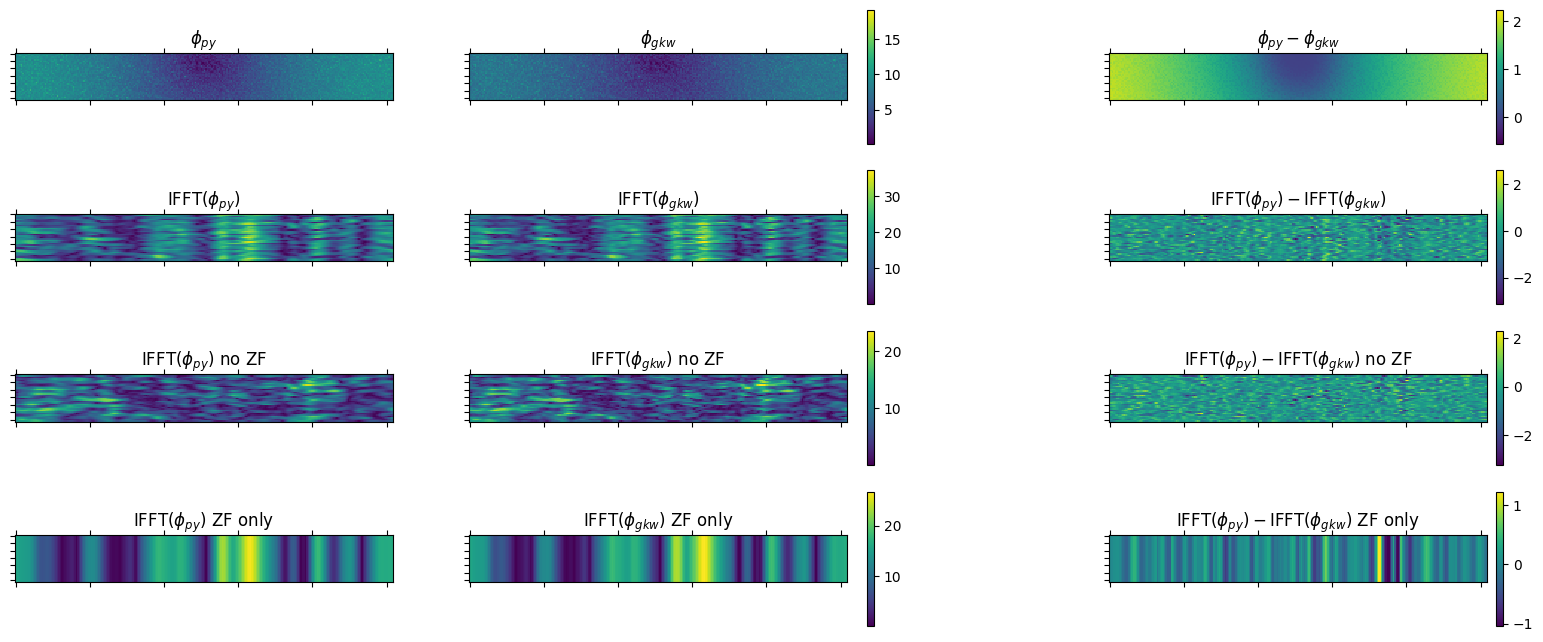

In [20]:
fig, ax = plt.subplots(4, 3, figsize=(20, 8))  # Changed to 4 rows

for i in range(4):
    for j in range(3):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].tick_params(labelleft=False, labelbottom=False)

# Prepare full fields
py_iphi = torch.fft.ifftshift(py_phi, dim=(0, 2))
py_iphi = torch.fft.ifftn(py_iphi, dim=(0, 2), norm="forward")

gkw_iphi = torch.fft.ifftshift(gkw_phi, dim=(0, 2))
gkw_iphi = torch.fft.ifftn(gkw_iphi, dim=(0, 2), norm="forward")

# Prepare turbulent fields (without zonal flow)
py_phi_turb = py_phi.clone()
py_phi_turb[:, :, 0] = 0.0
py_iphi_turb = torch.fft.ifftshift(py_phi_turb, dim=(0, 2))
py_iphi_turb = torch.fft.ifftn(py_iphi_turb, dim=(0, 2), norm="forward")

gkw_phi_turb = gkw_phi.clone()
gkw_phi_turb[:, :, 0] = 0.0
gkw_iphi_turb = torch.fft.ifftshift(gkw_phi_turb, dim=(0, 2))
gkw_iphi_turb = torch.fft.ifftn(gkw_iphi_turb, dim=(0, 2), norm="forward")

# Prepare zonal flow fields (only kx=0 mode)
py_phi_zf = py_phi.clone()
py_phi_zf[:, :, 1:] = 0.0  # Zero out all modes except kx=0
py_iphi_zf = torch.fft.ifftshift(py_phi_zf, dim=(0, 2))
py_iphi_zf = torch.fft.ifftn(py_iphi_zf, dim=(0, 2), norm="forward")

gkw_phi_zf = gkw_phi.clone()
gkw_phi_zf[:, :, 1:] = 0.0  # Zero out all modes except kx=0
gkw_iphi_zf = torch.fft.ifftshift(gkw_phi_zf, dim=(0, 2))
gkw_iphi_zf = torch.fft.ifftn(gkw_iphi_zf, dim=(0, 2), norm="forward")

cmap = None

# Row 0: Log magnitude plots
log_py = torch.log(py_phi).abs()[:, 7, :].T
log_gkw = torch.log(gkw_phi).abs()[:, 7, :].T
vmin_log, vmax_log = min(log_py.min(), log_gkw.min()), max(log_py.max(), log_gkw.max())

im00 = ax[0, 0].matshow(log_py, cmap=cmap, vmin=vmin_log, vmax=vmax_log)
ax[0, 0].set_title(r"$\phi_{py}$")
im01 = ax[0, 1].matshow(log_gkw, cmap=cmap, vmin=vmin_log, vmax=vmax_log)
ax[0, 1].set_title(r"$\phi_{gkw}$")
im02 = ax[0, 2].matshow(log_py - log_gkw, cmap=cmap)
ax[0, 2].set_title(r"$\phi_{py} - \phi_{gkw}$")

# Row 1: IFFT plots
ifft_py = torch.abs(py_iphi)[:, 7, :].T
ifft_gkw = torch.abs(gkw_iphi)[:, 7, :].T
vmin_ifft, vmax_ifft = min(ifft_py.min(), ifft_gkw.min()), max(
    ifft_py.max(), ifft_gkw.max()
)

im10 = ax[1, 0].matshow(ifft_py, cmap=cmap, vmin=vmin_ifft, vmax=vmax_ifft)
ax[1, 0].set_title(r"$\text{IFFT}(\phi_{py})$")
im11 = ax[1, 1].matshow(ifft_gkw, cmap=cmap, vmin=vmin_ifft, vmax=vmax_ifft)
ax[1, 1].set_title(r"$\text{IFFT}(\phi_{gkw})$")
im12 = ax[1, 2].matshow(ifft_py - ifft_gkw, cmap=cmap)
ax[1, 2].set_title(r"$\text{IFFT}(\phi_{py}) - \text{IFFT}(\phi_{gkw})$")

# Row 2: IFFT no ZF plots
ifft_py_turb = torch.abs(py_iphi_turb)[:, 7, :].T
ifft_gkw_turb = torch.abs(gkw_iphi_turb)[:, 7, :].T
vmin_turb, vmax_turb = min(ifft_py_turb.min(), ifft_gkw_turb.min()), max(
    ifft_py_turb.max(), ifft_gkw_turb.max()
)

im20 = ax[2, 0].matshow(ifft_py_turb, cmap=cmap, vmin=vmin_turb, vmax=vmax_turb)
ax[2, 0].set_title(r"$\text{IFFT}(\phi_{py})$ no ZF")
im21 = ax[2, 1].matshow(ifft_gkw_turb, cmap=cmap, vmin=vmin_turb, vmax=vmax_turb)
ax[2, 1].set_title(r"$\text{IFFT}(\phi_{gkw})$ no ZF")
im22 = ax[2, 2].matshow(ifft_py_turb - ifft_gkw_turb, cmap=cmap)
ax[2, 2].set_title(r"$\text{IFFT}(\phi_{py}) - \text{IFFT}(\phi_{gkw})$ no ZF")

# Row 3: Zonal flow only plots
ifft_py_zf = torch.abs(py_iphi_zf)[:, 7, :].T
ifft_gkw_zf = torch.abs(gkw_iphi_zf)[:, 7, :].T
vmin_zf, vmax_zf = min(ifft_py_zf.min(), ifft_gkw_zf.min()), max(
    ifft_py_zf.max(), ifft_gkw_zf.max()
)

im30 = ax[3, 0].matshow(ifft_py_zf, cmap=cmap, vmin=vmin_zf, vmax=vmax_zf)
ax[3, 0].set_title(r"$\text{IFFT}(\phi_{py})$ ZF only")
im31 = ax[3, 1].matshow(ifft_gkw_zf, cmap=cmap, vmin=vmin_zf, vmax=vmax_zf)
ax[3, 1].set_title(r"$\text{IFFT}(\phi_{gkw})$ ZF only")
im32 = ax[3, 2].matshow(ifft_py_zf - ifft_gkw_zf, cmap=cmap)
ax[3, 2].set_title(r"$\text{IFFT}(\phi_{py}) - \text{IFFT}(\phi_{gkw})$ ZF only")

# Add shared colorbars for first two columns in each row
fig.colorbar(im00, ax=[ax[0, 0], ax[0, 1]], location="right", pad=0.02)
fig.colorbar(im10, ax=[ax[1, 0], ax[1, 1]], location="right", pad=0.02)
fig.colorbar(im20, ax=[ax[2, 0], ax[2, 1]], location="right", pad=0.02)
fig.colorbar(im30, ax=[ax[3, 0], ax[3, 1]], location="right", pad=0.02)

# Add individual colorbars for difference plots
fig.colorbar(im02, ax=ax[0, 2], location="right", pad=0.02)
fig.colorbar(im12, ax=ax[1, 2], location="right", pad=0.02)
fig.colorbar(im22, ax=ax[2, 2], location="right", pad=0.02)
fig.colorbar(im32, ax=ax[3, 2], location="right", pad=0.02)


fig.savefig("tmp.png")

In [161]:
import torch
from typing import Dict, Tuple


def df_fft(df: torch.Tensor, norm: str = "backward"):
    df = df.movedim(0, -1).contiguous()
    df = torch.view_as_complex(df)
    df = torch.fft.fftn(df, dim=(3, 4), norm=norm)
    return torch.fft.ifftshift(df, dim=(3,))


def phi_to_spc(phi: torch.Tensor, out_shape: Tuple, norm: str = "forward"):
    # drop channels and apply fft
    phi = torch.fft.fftn(phi.squeeze(0), dim=(0, 2), norm=norm)
    phi = torch.fft.fftshift(phi, dim=(2, 0))
    # unpad (and positive half of spectra)
    nx, _, ny = out_shape
    phi = phi[..., phi.shape[-1] // 2 :]
    xpad = (phi.shape[0] - nx) // 2 + 1
    return phi[xpad : nx + xpad, :, :ny]


@torch.vmap
def pev_flux_df_phi(
    df: torch.Tensor,
    phi: torch.Tensor,
    geometry: Dict,
    aggregate: bool = True,
    magnitude: bool = False,
):
    """
    Computes particle, heat and momentum fluxes based on the distribution function (df)
    and electrostatic potential (phi).

    Args:
        df (torch.Tensor): 5D density function. Shape: (b, c, vpar, vmu, s, x, y).
        phi (torch.Tensor): 3D electrostatic potential. Shape: (b, 1, x, s, y).
        geometry (Dict): Dictionary containing geometry parameters and settings.
        aggregate (bool, optional): Whether to return the summed fluxes. Default: True.
        magnitude (bool, optional): Whether to use df and phi absolutes. Default: False.
    """
    ns, nx, ny = df.shape[3:]
    # df to fourier, phi to fourier and unpad
    df = df_fft(df)  # (par, mu, s, x, y)
    # expand geometry constants for broadcasting
    # grids
    krho = rearrange(geometry["krho"], "y -> 1 1 1 1 y")
    kxrh = rearrange(geometry["kxrh"], "x -> 1 1 1 x 1")
    ints = rearrange(geometry["ints"], "s -> 1 1 s 1 1")
    intmu = rearrange(geometry["intmu"], "mu -> 1 mu 1 1 1")
    intvp = rearrange(geometry["intvp"], "par -> par 1 1 1 1")
    vpgr = rearrange(geometry["vpgr"], "par -> par 1 1 1 1")
    mugr = rearrange(geometry["mugr"], "mu -> 1 mu 1 1 1")
    # settings
    little_g = rearrange(geometry["little_g"], "s three -> three 1 1 s 1 1")
    bn = rearrange(geometry["bn"], "s -> 1 1 s 1 1")
    efun = rearrange(geometry["efun"], "s -> 1 1 s 1 1")
    rfun = rearrange(geometry["rfun"], "s -> 1 1 s 1 1")
    bt_frac = rearrange(geometry["bt_frac"], "s -> 1 1 s 1 1")
    parseval = rearrange(geometry["parseval"], "y -> 1 1 1 1 y")
    mas, vthrat, signz = geometry["mas"], geometry["vthrat"], geometry["signz"]
    # gyroaveraged phi
    krloc = torch.sqrt(
        krho**2 * little_g[0] + 2 * krho * kxrh * little_g[1] + kxrh**2 * little_g[2]
    )
    bessel = torch.special.bessel_j0(
        mas * vthrat * krloc * torch.sqrt(2.0 * mugr / bn) / signz
    )

    phi_gyro = bessel * rearrange(phi, "x s y -> 1 1 s x y")
    # absolute values of df and phi
    if magnitude:
        df = -1j * torch.abs(df)
        phi_gyro = torch.abs(phi_gyro)
    # grid derivatives
    dum = parseval * ints * (efun * krho) * df
    dum1 = dum * torch.conj(phi_gyro)
    dum2 = dum1 * bn
    d3X = ints * geometry["d2X"]
    d3v = intmu * bn * intvp
    signB = geometry["signB"]
    # flux fields
    pflux_det = d3X * d3v * torch.imag(dum1)
    eflux_det = d3X * d3v * (vpgr**2 * torch.imag(dum1) + 2 * mugr * torch.imag(dum2))
    vflux_det = d3X * d3v * (torch.imag(dum1) * vpgr * rfun * bt_frac * signB)
    # sum total fluxes
    if aggregate:
        pflux_det = pflux_det.sum()
        eflux_det = eflux_det.sum()
        vflux_det = vflux_det.sum()
    return pflux_det, eflux_det, vflux_det

In [ ]:
directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"

KS = np.arange(1, 150, 5)

geometry = {}

geometry["parseval"] = torch.tensor([1.0] + [32.0] * (32 - 1), dtype=torch.float32)
geometry["signz"] = 1.0
geometry["vthrat"] = 1.0
geometry["tmp"] = 1.0
geometry["mas"] = 1.0
geometry["d2X"] = 1.0
geometry["signB"] = 1.0

geom = load_geom(os.path.join(directory, "geom.dat"))  # bn CHECK

geometry["kxrh"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "kxrh"))[0], dtype=torch.float32
)  # CHECK
geometry["krho"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "krho")).T[0] / geom["kthnorm"],
    dtype=torch.float32,
)  # CHECK

# mugr and intmu
mugr = np.zeros(8 + 1)
intmu = np.zeros(8 + 1)
mumax = 4.5
dvperp = np.sqrt(2.0 * mumax) / 8
for j in range(8 + 1):
    vperp = (j - 0.5) * dvperp
    mugr[j] = vperp**2 / 2.0
    intmu[j] = abs(np.pi * ((vperp + 0.5 * dvperp) ** 2 - (vperp - 0.5 * dvperp) ** 2))

geometry["intmu"] = torch.tensor(intmu[1:], dtype=torch.float32)  # CHECK?
geometry["mugr"] = torch.tensor(mugr[1:], dtype=torch.float32)  # CHECK?

geometry["intvp"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "intvp.dat"))[0], dtype=torch.float32
)  # CHECK
geometry["vpgr"] = torch.tensor(
    np.loadtxt(os.path.join(directory, "vpgr.dat"))[0], dtype=torch.float32
)

ints = np.concatenate(
    [np.array([0.0]), np.diff(np.loadtxt(os.path.join(directory, "sgrid")))]
)
ints[0] = ints[1]  # CHECK
geometry["ints"] = torch.tensor(ints, dtype=torch.float32)

geometry["efun"] = torch.tensor(-geom["E_eps_zeta"], dtype=torch.float32)  # CHECK

geometry["little_g"] = torch.tensor(
    np.stack([geom["g_zeta_zeta"], geom["g_eps_zeta"], geom["g_eps_eps"]], -1),
    dtype=torch.float32,
)

geometry["bn"] = torch.tensor(geom["bn"])
geometry["bt_frac"] = torch.tensor(geom["Bt_frac"])
geometry["rfun"] = torch.tensor(geom["R"])

########################################################################################

gkw = []
py = []

for k in KS:
    df = data[k].y.unsqueeze(0)
    gt_phi = data[k].y_poten
    flux = data[k].y_flux

    phi = phi_integral(df, geometry=geometry)

    pflux_det, eflux_det, _ = pev_flux_df_phi(df, phi, geometry=geometry)
    gkw.append(flux)
    py.append(eflux_det.sum())

    print(f"t = {k}\t E: {eflux_det.sum():.4f} (py) vs {flux:.4f} (gkw)")
    print(f"\t P: {pflux_det.sum():.4f} (py)")

fig, ax = plt.subplots(1, 1)

ax.plot(KS, gkw, lw=3, c=(32 / 255, 70 / 255, 125 / 255), label="gkw")
ax.plot(KS, py, lw=3, c=(255 / 255, 70 / 255, 125 / 255), label="py")

ax.grid()
fig.legend()
ax.set_xlabel(r"K", fontsize=20)
ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.tick_params(labelsize=14)